# Research update — Cacelli GBQIII validation figures
**2026-07-15**

Slide figures for the group-meeting update. The validation reproduces the Cacelli et al. (2004)
GBQIII slipped-parallel benzene crystal by melting a herringbone start at 100 K / 1 atm
(N = 400) under the corrected κ′ potential. Getting there took three tries.

Figures, in talk order:
1. **Dimer well vs κ′** — why the corrected potential selects slipped-parallel (and the typo doesn't).
2. **Run-5 convergence** — energy and density plateau: the engine as a converged instrument.
3. **Compress-before-melt race** — densification vs orientational memory, why the third run worked.
4. **Orientation map** — final-frame glass vs crystal.
5. **Structural fingerprints** — g(r) and P₂(r), crystal vs glass.
6. **Table V, side by side** — production averages vs their crystal and experiment.

In [1]:
import os
import pickle

import numpy as np
import matplotlib.pyplot as plt
from ase.db import connect
from dataclasses import replace

from asmcmc.potentials import CACELLI_POTENTIAL
from asmcmc.measurements import (
    RadialDistributionFunction,
    OrientationalCorrelationFunction,
)

# shared paths and constants used across the figures below
VALID = "../results/validation/100.0_6.324209e-07"
FIGDIR = "../results/validation/figures"
os.makedirs(FIGDIR, exist_ok=True)
SIGMA0 = 5.72   # A, GBQIII sigma0 (also the reduced-density length unit)
N_PART = 400

## Why the corrected κ′ matters: the slipped-parallel dimer well

`κ′` is the Gay–Berne well-depth anisotropy. The paper prints `κ′ = 4.39`; its equations imply the
reciprocal, `κ′ = 1/4.39 = 0.228`. That is not a small tweak — it changes the dimer energy landscape
qualitatively (energy vs separation for three canonical geometries below):

- **Corrected (`κ′ = 0.228`):** slipped-parallel is a **deep, well-defined well** (−2.53 kcal/mol),
  clearly below T-shaped (−1.94) and cofacial (−1.81). The crystal's building block is strongly selected.
- **Typo (`κ′ = 4.39`):** every well is **shallow (< 1 kcal/mol)** and pure face-to-face stacking is
  essentially **unbound** — no basin deep enough to nucleate the columnar crystal, so a herringbone
  start just vitrifies.

Slipped-parallel is the model's ground state under the corrected potential — which is *why* reproducing
it validates the sampler, and why the (non-ground-state) herringbone start is expected to convert.

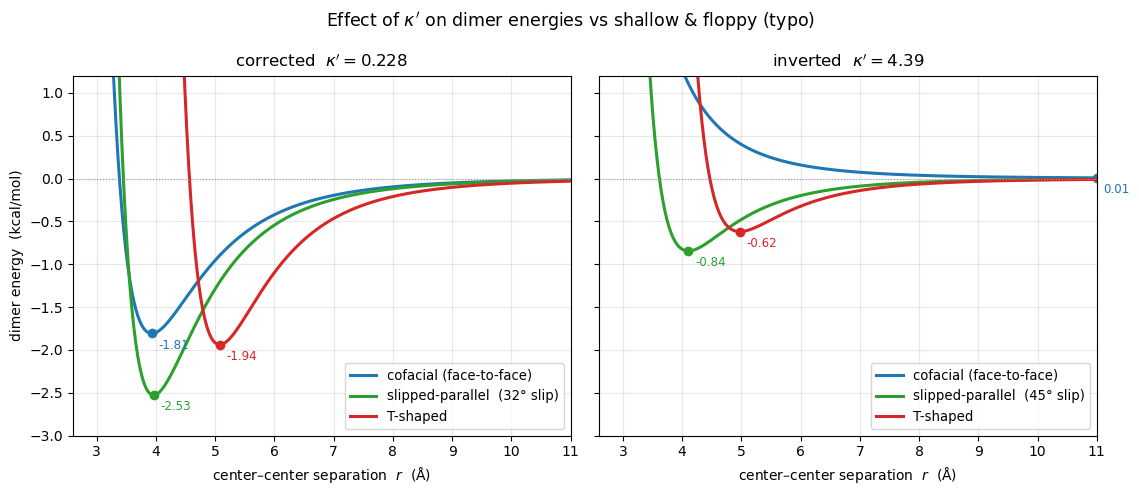

In [2]:
# --- Figure: the slipped-parallel dimer well, corrected vs typo kappa' -----
# Optimal SP slip angles (32 deg / 45 deg) come from a global 5-DOF dimer
# minimisation (partner orientation + separation direction + distance) of each
# potential; here we draw the energy vs separation for three canonical geometries.
EV2KCAL = 23.060541945329334
pot_corrected = CACELLI_POTENTIAL
pot_typo = replace(CACELLI_POTENTIAL, kappa_prime=4.39, name="cacelli_typo_kprime")
d = np.linspace(2.6, 11.0, 500)


def dimer_curve(pot, u2, slip_deg):
    """Pair energy (kcal/mol) vs centre-centre separation for a fixed geometry.

    u1 is the disc normal +z; u2 the partner's normal; the separation vector
    makes angle `slip_deg` with u1 (0 deg = stacked straight along the normal).
    """
    a = np.radians(slip_deg)
    rhat = np.array([np.sin(a), 0.0, np.cos(a)])
    M = len(d)
    U1 = np.tile([0, 0, 1.0], (M, 1))
    U2 = np.tile(np.asarray(u2, float), (M, 1))
    return pot.pair_energy(U1, U2, d[:, None] * rhat[None, :]) * EV2KCAL


panels = [("corrected  $\\kappa' = 0.228$", pot_corrected, 32),
          ("inverted  $\\kappa' = 4.39$", pot_typo, 45)]
geoms = [("cofacial (face-to-face)", [0, 0, 1.0], "cofacial", "tab:blue"),
         ("slipped-parallel", [0, 0, 1.0], "sp", "tab:green"),
         ("T-shaped", [1, 0, 0.0], "t", "tab:red")]

fig, axs = plt.subplots(1, 2, figsize=(11.5, 5), sharey=True)
for ax, (title, pot, sp_slip) in zip(axs, panels):
    slips = {"cofacial": 0, "sp": sp_slip, "t": 0}
    for label, u2, key, color in geoms:
        e = dimer_curve(pot, u2, slips[key])
        lab = label + (f"  ({sp_slip}° slip)" if key == "sp" else "")
        ax.plot(d, e, color=color, lw=2.2, label=lab)
        k = int(np.nanargmin(e))
        if e[k] < 0.3:                        # mark & annotate a genuine well
            ax.plot(d[k], e[k], "o", color=color, ms=6)
            ax.annotate(f"{e[k]:.2f}", (d[k], e[k]), textcoords="offset points",
                        xytext=(5, -11), fontsize=8.5, color=color)
    ax.axhline(0, color="0.6", lw=0.8, ls=":")
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("center–center separation  $r$  (Å)")
    ax.set_xlim(2.6, 11)
    ax.set_ylim(-3.0, 1.2)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9.5, loc="lower right")
axs[0].set_ylabel("dimer energy  (kcal/mol)")
fig.suptitle(
    r"Effect of $\kappa'$ on dimer energies "
    "vs shallow & floppy (typo)", fontsize=12.5)
fig.tight_layout()
fig.savefig(f"{FIGDIR}/dimer_kappa_prime.png", dpi=200, bbox_inches="tight")
plt.show()

## Run 5 converges: energy and density plateau

The winning run, continued for several million steps. Both the total energy and the reduced density
flatten after the initial collapse — the "is it equilibrated?" eyeball check. (The volume tail that
was still creeping at 200k steps has since settled.) This is the engine working as a converged instrument.

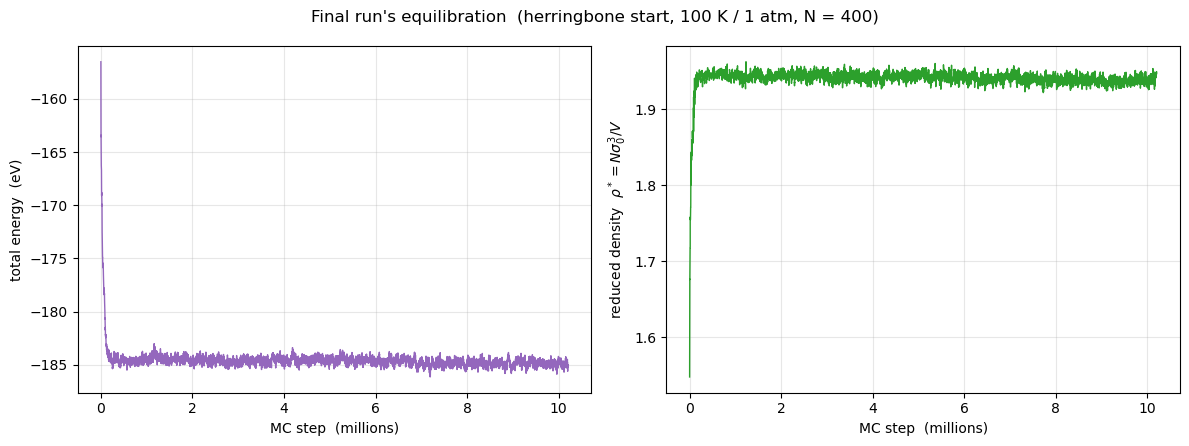

last-20% mean:  E = -184.89 eV,  rho* = 1.938  (over 5100 frames)


In [3]:
# --- Figure: run-5 convergence -- total energy & reduced density vs step --
steps, energy, rho = [], [], []
with connect(f"{VALID}/herringbone/equilibration.db") as db:
    for row in db.select():
        steps.append(row.step)
        energy.append(row.total_energy)
        rho.append(N_PART * SIGMA0 ** 3 / row.volume)
steps = np.asarray(steps); energy = np.asarray(energy); rho = np.asarray(rho)

fig, (ax_e, ax_r) = plt.subplots(1, 2, figsize=(12, 4.5))
ax_e.plot(steps / 1e6, energy, color="tab:purple", lw=1.0)
ax_e.set_ylabel("total energy  (eV)")
ax_r.plot(steps / 1e6, rho, color="tab:green", lw=1.0)
ax_r.set_ylabel(r"reduced density  $\rho^* = N\sigma_0^3/V$")
for ax in (ax_e, ax_r):
    ax.set_xlabel("MC step  (millions)")
    ax.grid(True, alpha=0.3)
fig.suptitle(
    "Final run's equilibration  "
    f"(herringbone start, 100 K / 1 atm, N = {N_PART})", fontsize=12)
fig.tight_layout()
fig.savefig(f"{FIGDIR}/run5_convergence.png", dpi=200, bbox_inches="tight")
plt.show()

tail = steps > 0.8 * steps.max()
print(f"last-20% mean:  E = {energy[tail].mean():.2f} eV,  "
      f"rho* = {rho[tail].mean():.3f}  (over {int(tail.sum())} frames)")

## The compress-before-melt race

Three herringbone-start equilibrations, same state point:

| run | box collapse | rotation width | outcome |
|-----|--------------|----------------|---------|
| **5** | fast (`vol_delt=0.025`) | capped (`max_or_delt=0.25` rad) | **slipped-parallel crystal** |
| **3** | slow (`vol_delt=0.001`) | *uncapped* | orientational glass |
| **1/2** | first attempt, 30 Å cutoff | — | glass |

Two diagnostics tell the whole story:

- **`ρ* = N σ₀³ / V`** — how compressed the box is.
- **P2-memory `= ⟨P₂(uᵢ(t)·uᵢ(0))⟩`** — how much of its *starting* orientation each particle
  still holds (1 = frozen, 0 = fully melted). Invariant under `u → −u`, so head/tail labelling
  doesn't matter.

In [4]:
# --- data: load the (sweep, rho*, P2-memory) trace for each run -----------
SIGMA0 = 5.72   # A -- GBQIII sigma0, also the reduced-density length unit
N_PART = 400

VALID = "../results/validation/100.0_6.324209e-07"
FIGDIR = "../results/validation/figures"
os.makedirs(FIGDIR, exist_ok=True)

RUNS = {
    "crystal": dict(
        path=f"{VALID}/herringbone/equilibration.db",
        label="fast collapse + capped rotation  (crystal)",
        color="tab:green", ls="-", lw=2.4, z=3),
    "or_melt": dict(
        path=f"{VALID}/herringbone_or_melt/equilibration.db",
        label="slow collapse + uncapped rotation  (glass)",
        color="tab:red", ls="-", lw=2.0, z=2),
 #   "vol_collapse": dict(
 #       path=f"{VALID}/herringbone_vol_collapse/equilibration.db",
 #       label="first attempt, 30 \u00c5 cutoff  (glass)",
 #       color="tab:orange", ls="--", lw=1.6, z=1),
}


def load_trace(path, stride=5):
    """(sweeps, rho*, P2-memory) sampled every `stride` recorded blocks.

    P2-memory retains the *initial* orientation: cos = u_i(t).u_i(0),
    P2 = mean((3 cos^2 - 1) / 2) over particles.
    """
    with connect(path) as db:
        rows = list(db.select())
    u0 = np.asarray(rows[0].data["or_vec"])
    sweeps, rho, p2 = [], [], []
    for row in rows[::stride]:
        u = np.asarray(row.data["or_vec"])
        cos = np.einsum("ij,ij->i", u, u0)
        sweeps.append(row.step / N_PART)
        rho.append(N_PART * SIGMA0 ** 3 / row.volume)
        p2.append(float(np.mean(0.5 * (3 * cos ** 2 - 1))))
    return np.asarray(sweeps), np.asarray(rho), np.asarray(p2)


# cache: run 3 has ~25k frames, so only read the dbs once per kernel
try:
    TRACES
except NameError:
    TRACES = {name: load_trace(r["path"]) for name, r in RUNS.items()}
    print("frames sampled:", {k: len(v[0]) for k, v in TRACES.items()})


frames sampled: {'crystal': 5100, 'or_melt': 5000}


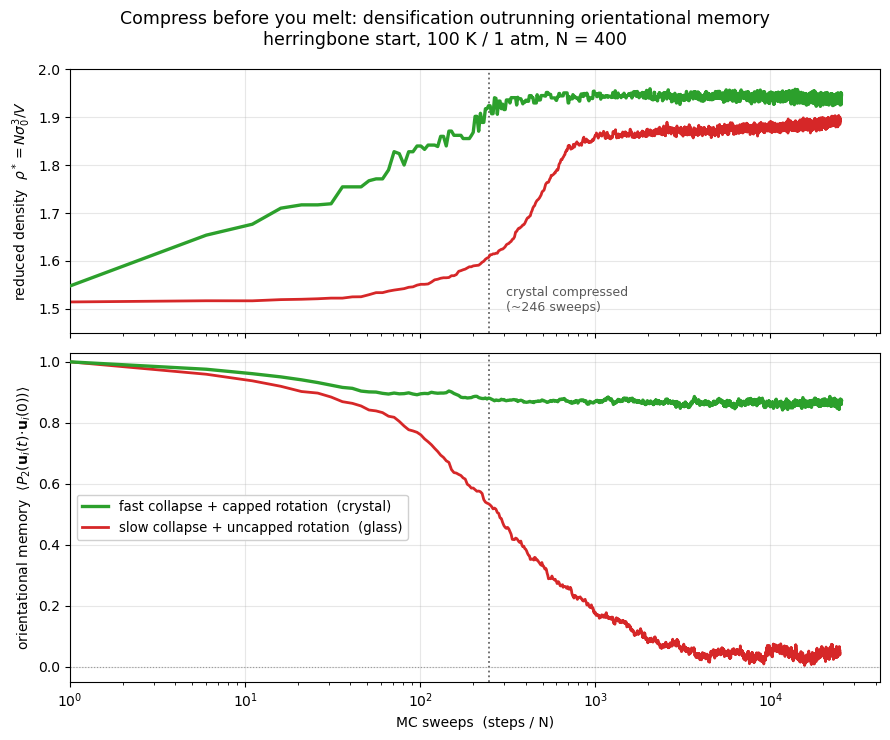

In [5]:
# --- Figure 1: densification vs orientational memory, versus MC sweeps ----
fig, (ax_rho, ax_mem) = plt.subplots(
    2, 1, figsize=(9, 7.5), sharex=True,
    gridspec_kw={"height_ratios": [1, 1.25]})

for name, r in RUNS.items():
    sw, rho, p2 = TRACES[name]
    ax_rho.plot(sw, rho, color=r["color"], ls=r["ls"], lw=r["lw"], zorder=r["z"])
    ax_mem.plot(sw, p2, color=r["color"], ls=r["ls"], lw=r["lw"],
                zorder=r["z"], label=r["label"])

# sweep at which the crystal run has essentially finished compressing
sw_c, rho_c, _ = TRACES["crystal"]
i_dense = int(np.searchsorted(rho_c, 0.98 * rho_c.max()))
sw_dense = sw_c[min(i_dense, len(sw_c) - 1)]
for ax in (ax_rho, ax_mem):
    ax.axvline(sw_dense, color="0.4", ls=":", lw=1.3, zorder=0)
ax_rho.text(sw_dense * 1.25, 1.49,
            f"crystal compressed\n(~{sw_dense:.0f} sweeps)",
            fontsize=9, color="0.35", va="bottom")

ax_rho.set_ylabel(r"reduced density  $\rho^*=N\sigma_0^3/V$")
ax_rho.set_ylim(1.45, 2.0)
ax_rho.grid(True, alpha=0.3)

ax_mem.set_ylabel(
    r"orientational memory  $\langle P_2(\mathbf{u}_i(t)\!\cdot\!\mathbf{u}_i(0))\rangle$")
ax_mem.set_xlabel("MC sweeps  (steps / N)")
ax_mem.set_xscale("log")
ax_mem.set_xlim(1, None)
ax_mem.set_ylim(-0.05, 1.03)
ax_mem.axhline(0.0, color="0.6", lw=0.8, ls=":")
ax_mem.grid(True, alpha=0.3)
ax_mem.legend(loc="center left", fontsize=9.5, framealpha=0.92)

fig.suptitle(
    "Compress before you melt: densification outrunning orientational memory\n"
    "herringbone start, 100 K / 1 atm, N = 400", fontsize=12.5)
fig.tight_layout()
fig.savefig(f"{FIGDIR}/compress_before_melt_race.png", dpi=200, bbox_inches="tight")
plt.show()


## Final-frame orientation map: glass vs crystal

Each particle's disc normal `u` is reduced to a tilt `θ` (from the `z` axis) and an in-plane
angle `ψ`, folded to the director symmetry (`u ≡ −u`). The crystal collapses onto **two sharp
spots 90° apart** — the two perpendicular slipped-parallel families. The glass is a smeared 
cloud. The "top-4-cell occupancy" quantifies the concentration.

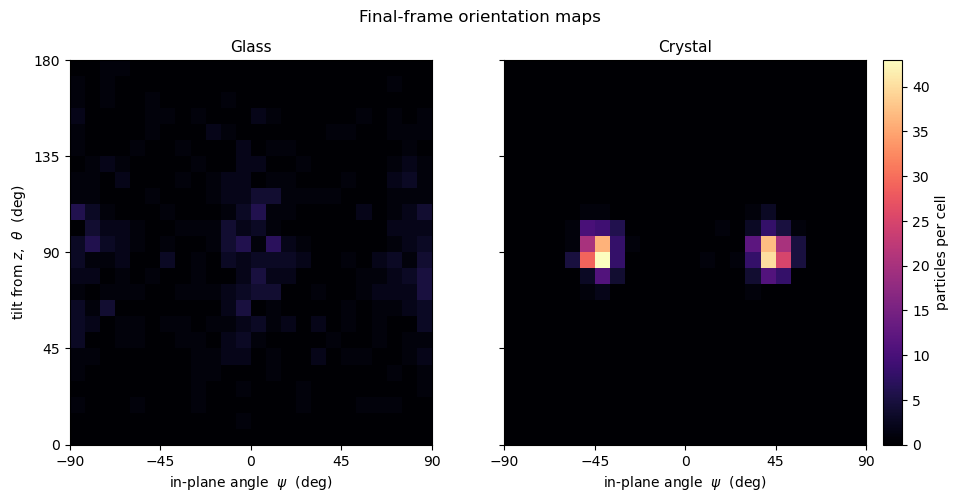

In [6]:
# --- Figure 2: final-frame orientation maps, glass vs crystal ------------
def orientation_map(path):
    with connect(path) as db:
        rows = list(db.select())
    u = np.asarray(rows[-1].data["or_vec"]).copy()
    u[u[:, 1] < 0] *= -1                       # director symmetry: fold u_y >= 0
    theta = np.degrees(np.arccos(np.clip(u[:, 2], -1, 1)))
    psi = np.degrees(np.arctan2(u[:, 1], u[:, 0]))
    psi = ((psi + 90) % 180) - 90              # wrap into [-90, 90), centred on the families
    return psi, theta


panels = [("or_melt", "Glass"), ("crystal", "Crystal")]
xedges = np.arange(-90, 91, 7.5)
yedges = np.arange(0, 181, 7.5)

data, vmax = [], 0.0
for name, _ in panels:
    psi, theta = orientation_map(RUNS[name]["path"])
    H, _, _ = np.histogram2d(psi, theta, bins=[xedges, yedges])
    data.append((psi, theta, H))
    vmax = max(vmax, H.max())

fig, axs = plt.subplots(1, 2, figsize=(11, 5), sharex=True, sharey=True)
for ax, (name, title), (psi, theta, H) in zip(axs, panels, data):
    pcm = ax.pcolormesh(xedges, yedges, H.T, cmap="magma", vmin=0, vmax=vmax)
    top4 = np.sort(H.ravel())[-4:].sum() / len(psi)
    ax.set_title(f"{title}", fontsize=11)
    ax.set_xlabel(r"in-plane angle  $\psi$  (deg)")
    ax.set_xticks([-90, -45, 0, 45, 90])
    ax.set_yticks([0, 45, 90, 135, 180])
axs[0].set_ylabel(r"tilt from $z$,  $\theta$  (deg)")

cbar = fig.colorbar(pcm, ax=axs, fraction=0.046, pad=0.02)
cbar.set_label("particles per cell")
fig.suptitle(
    "Final-frame orientation maps ", fontsize=12)
fig.savefig(f"{FIGDIR}/orientation_map_glass_vs_crystal.png", dpi=200, bbox_inches="tight")
plt.show()


## Structural fingerprints: crystal vs glass

Radial distribution `g(r)` (positional order) and the orientational correlation
`⟨P₂(cos θ_ij)⟩(r)` (neighbour alignment vs separation), each averaged over ~40 frames from the
converged tail. The crystal shows a **sharp, many-shell `g(r)`** and **strong contact alignment**
(P₂ ≈ 0.9) that turns *negative* by the second shell — the signature of two perpendicular families.
The glass is **washed out** in both: a broad `g(r)` and weak, short-ranged alignment.

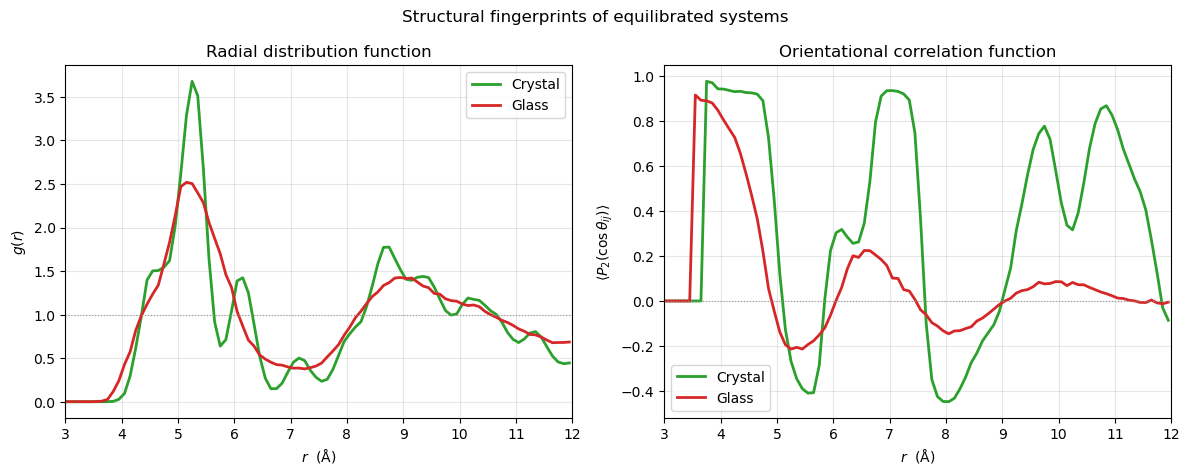

In [7]:
# --- Figure: structural fingerprints, crystal vs glass --------------------
def structural(path, tail_frac=0.5, n_frames=40, r_max=12.0, nbins=120):
    """RDF g(r) and orientational correlation P2(r), averaged over ~n_frames
    evenly-spaced frames from the converged tail (step >= tail_frac * max)."""
    with connect(path) as db:
        rows = list(db.select())
    tail = [r for r in rows if r.step >= tail_frac * rows[-1].step]
    pick = tail[:: max(1, len(tail) // n_frames)][:n_frames]
    rdf = RadialDistributionFunction(r_max, nbins)
    ocf = OrientationalCorrelationFunction(r_max, nbins)
    for row in pick:
        frame = row.toatoms()
        rdf.compute(frame, row.key_value_pairs, row.data)
        ocf.compute(frame, row.key_value_pairs, row.data)
    return rdf.finalize(), ocf.finalize()


# cache to disk: each run scans ~40 x 400-atom MIC distance matrices (~20 s).
# delete results/validation/figures/structural_cache.pkl to force a recompute.
struct_cache = f"{FIGDIR}/structural_cache.pkl"
try:
    STRUCT
except NameError:
    if os.path.exists(struct_cache):
        with open(struct_cache, "rb") as f:
            STRUCT = pickle.load(f)
    else:
        STRUCT = {"crystal": structural(f"{VALID}/herringbone/equilibration.db"),
                  "glass": structural(f"{VALID}/herringbone_or_melt/equilibration.db")}
        with open(struct_cache, "wb") as f:
            pickle.dump(STRUCT, f)

styles = {"crystal": ("Crystal", "tab:green"),
          "glass": ("Glass", "tab:red")}
fig, (ax_g, ax_s) = plt.subplots(1, 2, figsize=(12, 4.8))
for key, (label, color) in styles.items():
    rdf, ocf = STRUCT[key]
    ax_g.plot(rdf["r"], rdf["g_r"], color=color, lw=2.0, label=label)
    ax_s.plot(ocf["r"], ocf["s2_r"], color=color, lw=2.0, label=label)
ax_g.axhline(1.0, color="0.6", lw=0.8, ls=":")
ax_g.set_xlabel("$r$  (Å)")
ax_g.set_ylabel("$g(r)$")
ax_g.set_title("Radial distribution function")
ax_s.axhline(0.0, color="0.6", lw=0.8, ls=":")
ax_s.set_xlabel("$r$  (Å)")
ax_s.set_ylabel(r"$\langle P_2(\cos\theta_{ij})\rangle$")
ax_s.set_title("Orientational correlation function")
for ax in (ax_g, ax_s):
    ax.set_xlim(3, 12)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=10)
fig.suptitle("Structural fingerprints of equilibrated systems", fontsize=12)
fig.tight_layout()
fig.savefig(f"{FIGDIR}/structural_crystal_vs_glass.png", dpi=200, bbox_inches="tight")
plt.show()

## The payoff: Table V, side by side

Production averages (15 M steps after the equilibration above; tail half, 10-block errors)
against their GBQIII crystal at 100 K / 1 atm and experiment. Reading notes:

- **Unit cell by axis lineage.** Cacelli index their cell exactly this way — mean box edge ÷
  replication count — after *their* herringbone start transformed too. Our motif cell's (x, y, z)
  axes are the experimental (c, a, b), tiled 5×5×4, so each box edge is compared with the
  experimental axis it descended from. All three lattice parameters land within 1 % of theirs,
  reproducing their signature "wrong order **a > c > b**": both simulations transformed the
  herringbone along the same path.
- **η vs θ.** Their text quotes η ≈ 0.25, but Table V's θ = 46.6° back-solves through their own
  formula θ = π/2 − arccos √(⅔(η + ½)) to η = 0.292. Our production Q-tensor gives
  η = 0.289 ± 0.010 → θ = 46.5° — between their 46.6° and experiment's 46.4°.
- **ΔH_vap** follows their Fig-5 definition, ΔH_vap(T) = H_gas(T) − H(T) ≈ RT − H(T) per molecule;
  their value is read off Fig 5 by eye.
- Don't compare our crystal g(r)/P₂(r) to their Fig 8 — those curves are the **liquid at 300 K**.

The second cell prints the crystal fingerprints behind the numbers — two equal ⊥ families and
textbook slipped-parallel stacks (spacing, local P₂, slip angle) in the final production frame.

,this work,Cacelli GBQIII,experiment
V / molecule (Å³),96.52,96.8,116.0
ρ (g/mL),1.344,1.34,1.12
a (Å),8.75,8.75,7.37
b (Å),6.15,6.19,9.34
c (Å),7.17,7.15,6.74
η,0.289,0.292 (from θ),≈0.287 (from θ)
θ (°),46.5,46.6,46.4
ΔH_vap (kcal/mol),10.86,≈10.2 (Fig 5),≈11 (Fig 5)


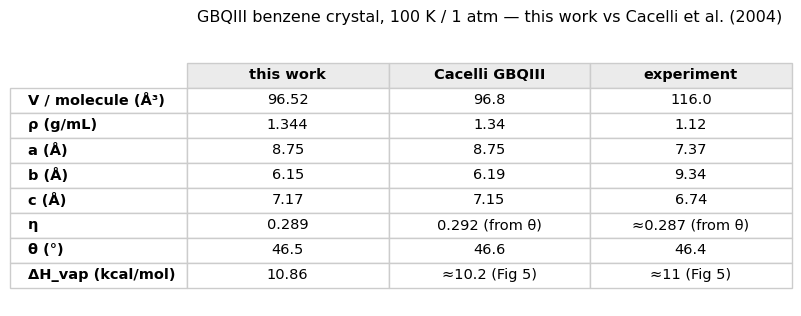

In [11]:
# --- Table: production averages vs Cacelli et al. Table V ------------------
import json
import sqlite3

import pandas as pd

from asmcmc.initialize import _herringbone_reps, _load_herringbone_motif

T, P = 100.0, 6.324209e-7      # K, eV/A^3  (1 atm)
EV2KCAL = 23.060541945329334   # kcal/mol per eV
R_KCAL = 1.9872042586e-3       # gas constant, kcal/mol/K
M_BENZ = 78.114                # benzene molar mass, g/mol

# read energy/vol/cell straight from sqlite: ase.db row iteration also decodes
# positions + per-particle arrays, far slower over the 37.5k production rows
con = sqlite3.connect(f"{VALID}/herringbone/simulation.db")
raw = con.execute("SELECT key_value_pairs, cell FROM systems ORDER BY id").fetchall()
con.close()
n_rows = len(raw)
kv = [json.loads(k) for k, _ in raw]
U = np.array([d["total_energy"] for d in kv])
V = np.array([d["vol"] for d in kv])
box = np.array([np.frombuffer(c, np.float64).reshape(3, 3).diagonal() for _, c in raw])


def block_err(a, nb=10):
    m = np.array([b.mean() for b in np.array_split(a, nb)])
    return m.std(ddof=1) / np.sqrt(nb)


half = n_rows // 2                # tail half (U/V thirds agree to <0.03%: converged)
H_mol = (U + P * V)[half:] / N_PART
v_mol = V[half:].mean() / N_PART
v_mol_err = block_err(V[half:]) / N_PART
rho_gml = M_BENZ / (v_mol * 0.60221408)        # /(N_A x 1e-24)
dHvap = R_KCAL * T - H_mol.mean() * EV2KCAL    # their Fig-5 definition: ~ RT - H(T)

# unit cell, their procedure: mean box edge / supercell reps -- they index their
# own post-transformation cell the same naive way.  The motif cell's (x, y, z)
# axes are the experimental (c, a, b), so relabel each box axis by length rank
# to compare it with the experimental axis it descended from.
*_, motif_edges = _load_herringbone_motif(None)
reps = np.array(_herringbone_reps(N_PART, motif_edges))
abc = dict(zip(np.array(["c", "a", "b"])[np.argsort(np.argsort(motif_edges))],
               box[half:].mean(axis=0) / reps))

# production Q-tensor order parameter -> tilt via their formula
with open(f"{VALID}/herringbone/measurements.pkl", "rb") as f:
    meas = pickle.load(f)
eta, eta_std = meas["nematic"]["S"], meas["nematic"]["S_std"]


def theta_deg(e):
    """Their tilt-from-order formula: theta = pi/2 - arccos sqrt(2/3 (eta + 1/2))."""
    return 90.0 - np.degrees(np.arccos(np.sqrt(2.0 / 3.0 * (e + 0.5))))


th = theta_deg(eta)
th_err = (theta_deg(eta + 1e-4) - th) / 1e-4 * eta_std

# references: Table V (cell, theta; exp extrapolated to 100 K) + Fig 5 read by
# eye (dHvap); their eta back-solved from Table V theta through the formula above
table = pd.DataFrame(
    {
        "this work": [
            f"{v_mol:.2f}", f"{rho_gml:.3f}",
            f"{abc['a']:.2f}", f"{abc['b']:.2f}", f"{abc['c']:.2f}",
            f"{eta:.3f}", f"{th:.1f}", f"{dHvap:.2f}",
        ],
        "Cacelli GBQIII": ["96.8", "1.34", "8.75", "6.19", "7.15",
                           "0.292 (from θ)", "46.6", "≈10.2 (Fig 5)"],
        "experiment": ["116.0", "1.12", "7.37", "9.34", "6.74",
                       "≈0.287 (from θ)", "46.4", "≈11 (Fig 5)"],
    },
    index=["V / molecule (Å³)", "ρ (g/mL)", "a (Å)", "b (Å)", "c (Å)",
           "η", "θ (°)", "ΔH_vap (kcal/mol)"],
)
display(table)

# slide-ready render of the same table
fig, ax = plt.subplots(figsize=(7.8, 3.4))
ax.axis("off")
tab = ax.table(cellText=table.values, rowLabels=table.index,
               colLabels=table.columns, cellLoc="center", loc="center")
tab.auto_set_font_size(False)
tab.set_fontsize(10.5)
tab.scale(1, 1.5)
for (r, c), cell in tab.get_celld().items():
    cell.set_edgecolor("0.8")
    if r == 0 or c == -1:
        cell.set_text_props(weight="bold")
    if r == 0:
        cell.set_facecolor("0.92")
ax.set_title("GBQIII benzene crystal, 100 K / 1 atm — this work vs Cacelli et al. (2004)",
             fontsize=11.5, pad=16)
fig.savefig(f"{FIGDIR}/cacelli_table_v_comparison.png", dpi=200, bbox_inches="tight")
plt.show()

In [10]:
# --- Final production frame: the crystal fingerprints behind the table -----
with connect(f"{VALID}/herringbone/simulation.db") as db:
    last = db.get(id=n_rows)
u = np.asarray(last.data["or_vec"])
u = u / np.linalg.norm(u, axis=1, keepdims=True)
pos = last.toatoms().get_positions()
L = np.asarray(last.data["cell"]).diagonal()

# two families: 2-means on axes (sign-invariant), seeded far apart
mA = u[0].copy()
mB = u[np.argmin(np.abs(u @ mA))].copy()
for _ in range(20):
    in_A = np.abs(u @ mA) >= np.abs(u @ mB)

    def axis_mean(w):
        _, vec = np.linalg.eigh((w[:, :, None] * w[:, None, :]).mean(axis=0))
        return vec[:, -1]

    mA, mB = axis_mean(u[in_A]), axis_mean(u[~in_A])
mutual = np.degrees(np.arccos(np.clip(abs(float(mA @ mB)), 0, 1)))

# face-contact (in-stack) pairs: min-image r < 4.6 A
dr = pos[:, None] - pos[None, :]
dr -= np.rint(dr / L) * L
dist = np.linalg.norm(dr, axis=-1)
i, j = np.triu_indices(len(pos), k=1)
c = dist[i, j] < 4.6
r_c = dist[i, j][c]
p2 = (1.5 * np.einsum("ij,ij->i", u[i[c]], u[j[c]]) ** 2 - 0.5).mean()
rhat = dr[i[c], j[c]] / r_c[:, None]
slip = np.degrees(np.arccos(np.clip(np.abs(np.einsum("ij,ij->i", rhat, u[i[c]])), 0, 1)))
stacked = np.unique(np.r_[i[c], j[c]]).size

print(f"families: {in_A.sum()}/{(~in_A).sum()} particles, mean axes {mutual:.1f} deg apart")
print("  (their Fig 7b: two equal spots 90 deg apart; experiment ~2x46.4 = 92.8 deg)")
print(f"face contacts (r < 4.6 A): {c.sum()} pairs, {stacked}/{len(pos)} particles in stacks")
print(f"  stack spacing r = {r_c.mean():.2f} ± {r_c.std():.2f} A  (their relaxed SP dimer minimum ~4.3 A)")
print(f"  local P2 = {p2:.3f}  (the glass run: 0.54),  slip angle = {slip.mean():.0f} ± {slip.std():.0f} deg")

families: 200/200 particles, mean axes 85.4 deg apart
  (their Fig 7b: two equal spots 90 deg apart; experiment ~2x46.4 = 92.8 deg)
face contacts (r < 4.6 A): 253 pairs, 363/400 particles in stacks
  stack spacing r = 4.41 ± 0.13 A  (their relaxed SP dimer minimum ~4.3 A)
  local P2 = 0.933  (the glass run: 0.54),  slip angle = 50 ± 6 deg
